In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, chi2

In [2]:
# 1. Load the cleaned data
df = pd.read_csv('../data/cleaned_heart_disease.csv')
X = df.drop('target', axis=1)
y = df['target']


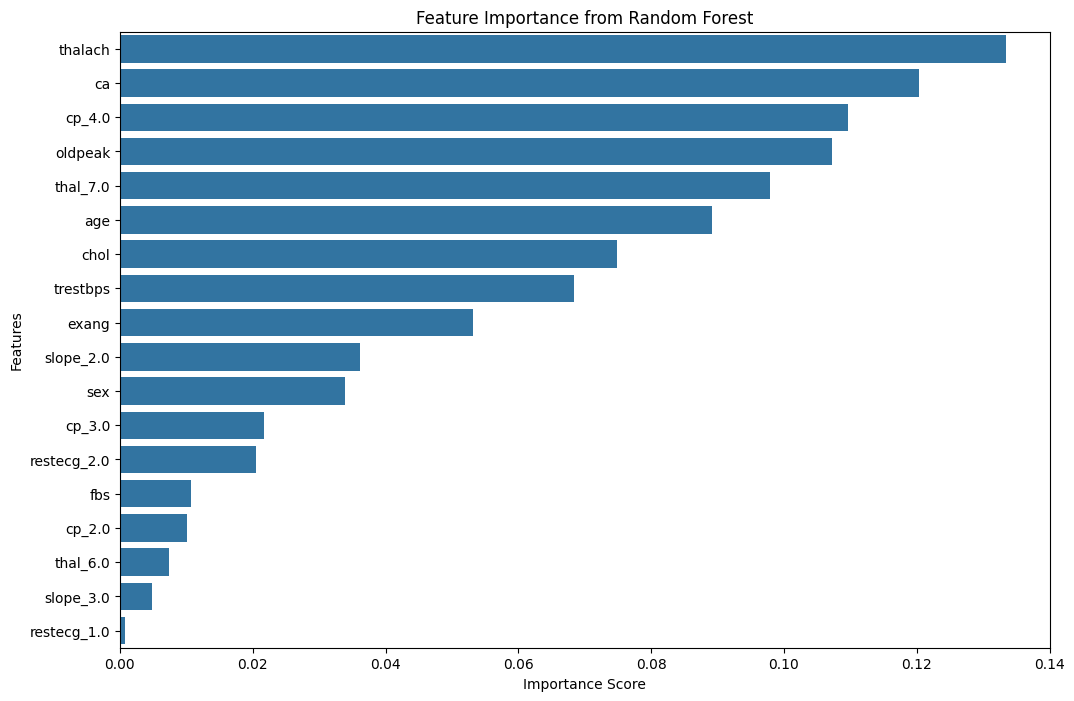

Top 10 features from Random Forest:
thalach      0.133378
ca           0.120275
cp_4.0       0.109580
oldpeak      0.107169
thal_7.0     0.097870
age          0.089141
chol         0.074914
trestbps     0.068434
exang        0.053206
slope_2.0    0.036174
dtype: float64


In [3]:
# 2. Method 1: Feature Importance from Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=importances, y=importances.index)
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

print("Top 10 features from Random Forest:")
print(importances.head(10))

In [4]:
# 3. Method 2: Recursive Feature Elimination (RFE)
# Let's aim to select the top 10 features
logreg = LogisticRegression(max_iter=1000)
rfe = RFE(estimator=logreg, n_features_to_select=10)
rfe.fit(X, y)

selected_features_rfe = X.columns[rfe.support_]
print("\nFeatures selected by RFE:")
print(selected_features_rfe)


Features selected by RFE:
Index(['sex', 'thalach', 'exang', 'oldpeak', 'ca', 'cp_2.0', 'cp_4.0',
       'restecg_2.0', 'slope_2.0', 'thal_7.0'],
      dtype='object')


In [5]:
# 4. Select Final Features
# Based on Random Forest importance, let's select the top 12 features.
final_features = importances.head(12).index.tolist()
print("\nFinal selected features for modeling:")
print(final_features)

# Create a new DataFrame with only the selected features and the target
df_selected = df[final_features + ['target']]
df_selected.to_csv('../data/selected_features_heart_disease.csv', index=False)
print("\nDataset with selected features saved.")


Final selected features for modeling:
['thalach', 'ca', 'cp_4.0', 'oldpeak', 'thal_7.0', 'age', 'chol', 'trestbps', 'exang', 'slope_2.0', 'sex', 'cp_3.0']

Dataset with selected features saved.
